In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt


In [6]:
# Copy data
df = pd.read_csv("cleaned_data.csv")

# Compute max_progress per Opportunity
max_progress_per_opportunity = df.groupby('Opportunity')['Progress'].max()
df['max_progress'] = df['Opportunity'].map(max_progress_per_opportunity)


In [7]:
# Normalize Progress to 0-1
df['Progress_normalized'] = (df['Progress'] - 1) / (df['max_progress'] - 1)
df['Progress_normalized'] = df['Progress_normalized'].fillna(0)  # handle max_progress = 1


In [8]:
categorical_cols = ['Industry', 'Company', 'Gender', 'Race', 'Institution', 'Qualification']
label_encoders = {}

for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col + '_encoded'] = le.fit_transform(df[col])
        label_encoders[col] = le


In [9]:
# Select features
feature_columns = ['Age', 'Aggregate', 'NumCandidates'] + [col + '_encoded' for col in categorical_cols if col in df.columns]
discipline_cols = [col for col in df.columns if col.startswith('Discipline_')]
feature_columns.extend(discipline_cols)

# Prepare X and y
X = df[feature_columns]
y = df['Progress_normalized']


In [10]:
# Stratify by rounded normalized progress
y_strat = np.round(df['Progress_normalized'] * 10)
X_train, X_validation, y_train, y_validation = train_test_split(
    X, df['Progress_normalized'], test_size=0.2, random_state=42, stratify=y_strat
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_validation.shape[0]}")


Training set size: 64425
Validation set size: 16107


In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

# Predict normalized progress
y_train_pred = np.clip(model.predict(X_train), 0, 1)
y_val_pred = np.clip(model.predict(X_validation), 0, 1)


In [12]:
train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_validation, y_val_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_validation, y_val_pred)
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_validation, y_val_pred)

print("\n" + "="*40)
print("MODEL PERFORMANCE")
print("="*40)
print(f"Training   - MSE: {train_mse:.4f}, MAE: {train_mae:.4f}, R²: {train_r2:.4f}")
print(f"Validation - MSE: {val_mse:.4f}, MAE: {val_mae:.4f}, R²: {val_r2:.4f}")



MODEL PERFORMANCE
Training   - MSE: 0.0404, MAE: 0.1366, R²: 0.1032
Validation - MSE: 0.0408, MAE: 0.1373, R²: 0.0937


In [13]:
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\nIntercept: {model.intercept_:.4f}")
print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))



Intercept: 0.0094

Top 10 Most Important Features:
                                         Feature  Coefficient
                            Discipline_Marketing     0.130485
                                  Discipline_Law    -0.085256
Discipline_Electrical and Electronic Engineering     0.078114
               Discipline_Information Technology     0.032489
                     Discipline_Computer Science     0.030978
                                Discipline_Other     0.026296
                          Discipline_Investments    -0.019836
                                  Gender_encoded    -0.016577
                  Discipline_Information Systems     0.014504
              Discipline_Accounting and Auditing     0.013926


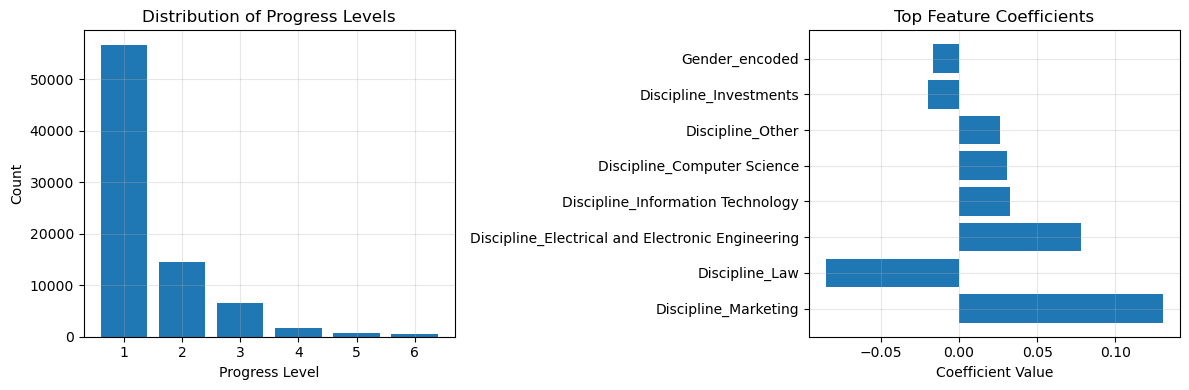

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot progress distribution
progress_counts = df['Progress'].value_counts().sort_index()
ax1.bar(progress_counts.index, progress_counts.values)
ax1.set_xlabel('Progress Level')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Progress Levels')
ax1.grid(True, alpha=0.3)

# Plot top coefficients
top_features = feature_importance.head(8)
ax2.barh(range(len(top_features)), top_features['Coefficient'])
ax2.set_yticks(range(len(top_features)))
ax2.set_yticklabels(top_features['Feature'])
ax2.set_xlabel('Coefficient Value')
ax2.set_title('Top Feature Coefficients')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [15]:
def predict_progress(new_data):
    """Predict progress for new data, scaled by opportunity max_progress"""
    new_df = new_data.copy()

    # Encode categorical variables
    for col in categorical_cols:
        if col in new_df.columns and col in label_encoders:
            new_df[col + '_encoded'] = label_encoders[col].transform(new_df[col])

    # Ensure max_progress column exists
    if 'max_progress' not in new_df.columns:
        new_df['max_progress'] = new_df['Opportunity'].map(max_progress_per_opportunity)

    # Select features and predict normalized progress
    X_new = new_df[feature_columns]
    y_pred_normalized = np.clip(model.predict(X_new), 0, 1)

    # Scale back to actual progress
    y_pred_actual = 1 + y_pred_normalized * (new_df['max_progress'] - 1)
    return y_pred_actual

print(f"\nModel ready! Use predict_progress() to make predictions on new data.")



Model ready! Use predict_progress() to make predictions on new data.
